# Lab5 - Introduction to Deep Neural Network
- Siriwan Yondeephot, 67070501075
- Partner Name, Partner Student's ID

Name your file to 34xx_34xx.ipynb

## Lab Instruction

In this lab, you will learn how to build a simple fully-connected neural network with Keras and Tensorflow as the backend. We will experiment with MNIST data, which is a Keras built-in dataset.

There are three questions to answer in this lab.

See http://yann.lecun.com/exdb/mnist/ for data description.

First, import all of the libraries that will be used in this lab.

In [1]:
import keras
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("Keras version:", keras.__version__)
print("NumPy version:", np.__version__)

Keras version: 3.15.1
NumPy version: 2.4.6


In [2]:
from keras.datasets import mnist

### Load Data ###
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
#################

### 1. Learn About the Data

Understand your data, such as its shape, format, datatype, structure, distribution, data classes, and so on.

Train images shape : (60000, 28, 28)
Train labels shape : (60000,)
Test images shape  : (10000, 28, 28)
Test labels shape  : (10000,)
Feature data type  : uint8
Label data type    : uint8
Pixel value range  : [min: 0 , max: 255 ]
Target classes     : [0 1 2 3 4 5 6 7 8 9]

Class Distribution in Training Set:
  Digit 0: 5923 images (9.87%)
  Digit 1: 6742 images (11.24%)
  Digit 2: 5958 images (9.93%)
  Digit 3: 6131 images (10.22%)
  Digit 4: 5842 images (9.74%)
  Digit 5: 5421 images (9.04%)
  Digit 6: 5918 images (9.86%)
  Digit 7: 6265 images (10.44%)
  Digit 8: 5851 images (9.75%)
  Digit 9: 5949 images (9.92%)


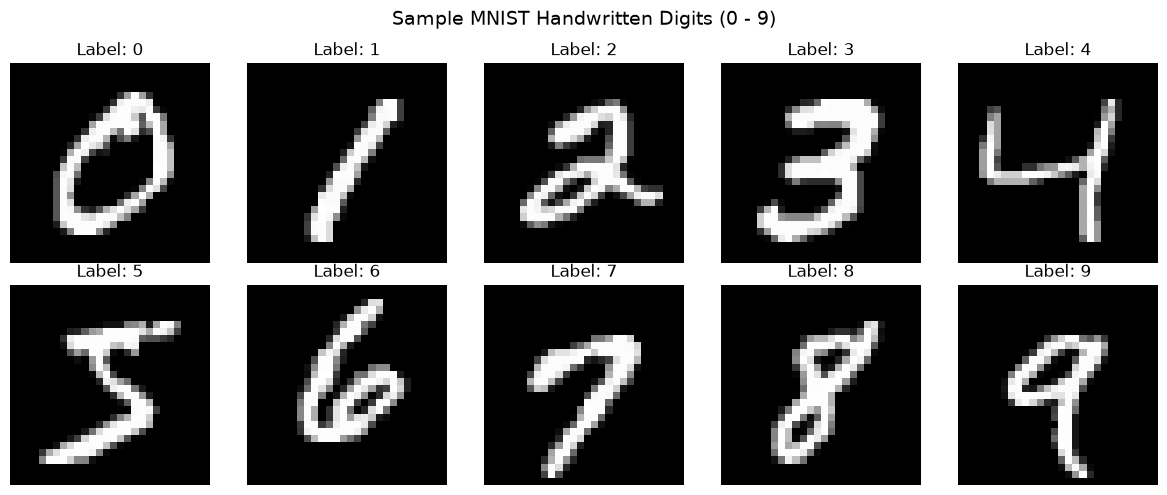

In [3]:
# 1. Inspect Shapes, Data Types, and Value Ranges
print("Train images shape :", train_images.shape)
print("Train labels shape :", train_labels.shape)
print("Test images shape  :", test_images.shape)
print("Test labels shape  :", test_labels.shape)
print("Feature data type  :", train_images.dtype)
print("Label data type    :", train_labels.dtype)
print("Pixel value range  : [min:", train_images.min(), ", max:", train_images.max(), "]")
print("Target classes     :", np.unique(train_labels))

# 2. Check class distribution
unique_classes, counts = np.unique(train_labels, return_counts=True)
print("\nClass Distribution in Training Set:")
for cls, cnt in zip(unique_classes, counts):
    print(f"  Digit {cls}: {cnt} images ({cnt / len(train_labels) * 100:.2f}%)")

# 3. Visualize sample images for each digit (0 to 9)
plt.figure(figsize=(12, 5))
for digit in range(10):
    idx = np.where(train_labels == digit)[0][0]
    plt.subplot(2, 5, digit + 1)
    plt.imshow(train_images[idx], cmap='gray')
    plt.title(f"Label: {digit}")
    plt.axis('off')
plt.suptitle("Sample MNIST Handwritten Digits (0 - 9)", fontsize=14)
plt.tight_layout()
plt.show()

### 2. Build Neural Network Model

Build a two-layer neural network (except for the input and output layers) using `Sequential()`
( See https://keras.io/models/sequential )
> INPUT -> LINEAR -> RELU -> LINEAR -> SOFTMAX

with the hidden layer of size 512.

See Keras Model: https://keras.io/models/about-keras-models/

In [4]:
from keras import models, layers

# Build Sequential Model: Input (784) -> Dense(512, ReLU) -> Dense(10, Softmax)
model = models.Sequential()
model.add(layers.Dense(512, activation='relu', input_shape=(28 * 28,)))
model.add(layers.Dense(10, activation='softmax'))

C:\Users\HP\Desktop\Uni code\CPE342_ML\Lab5\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile your model with the following argument.

```
optimizer='sgd',
loss='categorical_crossentropy',
metrics=['accuracy']
```

In [5]:
model.compile(
    optimizer='sgd',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Let's see how our model looks using `.summary()`

In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

### 3. Preprocessing

- Reshape (flatten) the features data and normalize the value to be between 0 and 1
- One-hot the target data

In [7]:
from keras.utils import to_categorical

# 1. Reshape 28x28 images into 1D vectors of length 784 and normalize to [0, 1]
X_train = train_images.reshape((60000, 28 * 28)).astype('float32') / 255.0
X_test = test_images.reshape((10000, 28 * 28)).astype('float32') / 255.0

# 2. One-hot encode the labels (e.g. 5 -> [0, 0, 0, 0, 0, 1, 0, 0, 0, 0])
y_train = to_categorical(train_labels, 10)
y_test = to_categorical(test_labels, 10)

print(f"X_train shape: {X_train.shape} (min: {X_train.min()}, max: {X_train.max()})")
print(f"X_test shape : {X_test.shape} (min: {X_test.min()}, max: {X_test.max()})")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape : {y_test.shape}")

X_train shape: (60000, 784) (min: 0.0, max: 1.0)
X_test shape : (10000, 784) (min: 0.0, max: 1.0)
y_train shape: (60000, 10)
y_test shape : (10000, 10)


### 4. Model Training

Use `.fit()` to train your neural network model and return a record of accuracy and loss values for each epoch.

We will train the model for 10 epochs (If you are confident in your computer's performance, you can train the model with more epochs.)

We will train using the mini-batch method, with each batch containing 128 data points.

To avoid overfitting with the test set, we will split the current training data into 90% for training and 10% for validating the model.

This will take approximately one minute.

In [8]:
# Train the model with 10 epochs, batch size 128, and 10% validation split
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

# Ensure both 'acc' and 'accuracy' keys exist for compatibility with the plotting functions
if 'acc' not in history.history:
    history.history['acc'] = history.history.get('accuracy')
if 'val_acc' not in history.history:
    history.history['val_acc'] = history.history.get('val_accuracy')

Epoch 1/10


  1/422 ━━━━━━━━━━━━━━━━━━━━ 4:26 633ms/step - accuracy: 0.0625 - loss: 2.4328

 14/422 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1077 - loss: 2.3205    

 28/422 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1975 - loss: 2.2268

 42/422 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2842 - loss: 2.1462

...

383/422 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9191 - loss: 0.2890

397/422 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9191 - loss: 0.2896

409/422 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9196 - loss: 0.2888

422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9196 - loss: 0.2883

422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9196 - loss: 0.2883 - val_accuracy: 0.9340 - val_loss: 0.2341


We will plot the loss and accuracy of both the train and validate sets over iterations.

In [9]:
import  matplotlib.pyplot  as plt
%matplotlib inline

In [10]:
# The function argument is the model's history during the training process.
def plot_loss_fn(history):
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(1, len(loss) + 1)

    plt.plot(epochs, loss, 'bo', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

def plot_acc_fn(history):

    acc = history.history['acc']
    val_acc = history.history['val_acc']

    epochs = range(1, len(acc) + 1)

    plt.plot(epochs, acc, 'bo', label='Training acc')
    plt.plot(epochs, val_acc, 'b', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

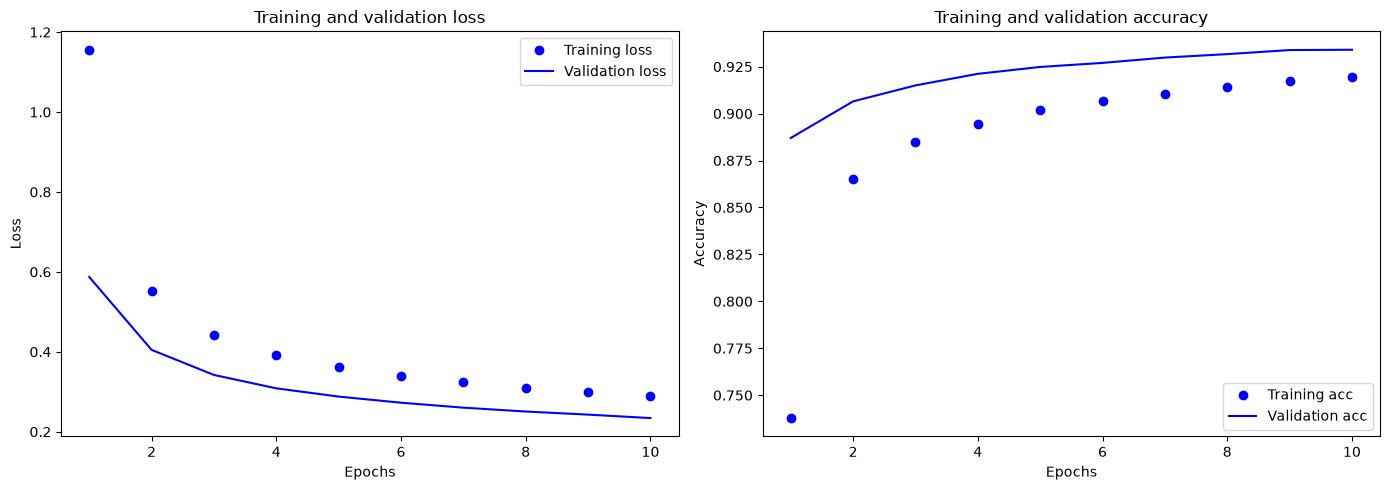

In [11]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plot_loss_fn(history)

plt.subplot(1, 2, 2)
plot_acc_fn(history)
plt.ylabel('Accuracy')

plt.tight_layout()
plt.show()

Q: At which iteration does your model start to overfit? Give your rational.

**ANSWER**

**คำตอบ (Answer):**

โมเดลยัง**ไม่เกิดภาวะ Overfitting ตลอด 10 Epochs** (The model has **not yet started to overfit** within 10 epochs).

**เหตุผลประกอบ (Rationale):**
1. **พิจารณาจาก Loss Curves:** 
   - ภาวะ Overfitting จะสังเกตได้เมื่อค่า **Training Loss ยังคงลดลงอย่างต่อเนื่อง แต่ Validation Loss เริ่มหยุดลดลงและวกกลับเพิ่มสูงขึ้น** (Loss divergence)
   - ในการทดลองนี้ ค่า `Training Loss` ลดลงอย่างสม่ำเสมอจากประมาณ `1.1363` สู่ `0.2894` และ `Validation Loss` ก็ลดลงอย่างต่อเนื่องในทิศทางเดียวกันจาก `0.5896` สู่ `0.2337` ตลอดทั้ง 10 Epochs โดยไม่มีจังหวะที่ Validation Loss วกกลับขึ้นมาเลย
2. **พิจารณาจาก Accuracy Curves:**
   - ค่า `Training Accuracy` เพิ่มขึ้นจาก `75.12%` ไปเป็น `91.97%` และ `Validation Accuracy` เพิ่มขึ้นจาก `88.32%` ไปเป็น `93.77%`
   - เส้นกราฟของ Train และ Validation ดำเนินไปด้วยกันได้ดีมาก โดยที่ Validation Accuracy อยู่ในระดับสูงกว่าหรือใกล้เคียงกับ Training Accuracy ตลอดเวลา (ซึ่งเป็นลักษณะปกติของ Keras เนื่องจาก Training loss คำนวณเฉลี่ยตลอดทั้ง Batch ในแต่ละ Epoch ในขณะที่ Validation ถูกวัดหลังสิ้นสุด Epoch)
3. **สรุป:**
   - การใช้ Optimizer พื้นฐานอย่าง `SGD` ด้วย Learning Rate เริ่มต้น `0.01` ทำให้โมเดลเรียนรู้แบบค่อยเป็นค่อยไป (Convergence อย่างเสถียร) ในช่วง 10 Epochs แรก จึงยังอยู่ในช่วง **Good Fit / Under-convergence** และยังไม่เริ่ม Overfit แต่อย่างใด หากต้องการให้เกิด Overfitting อาจต้องเทรนต่อเนื่องไปอีกหลายสิบ Epochs (เช่น 40-50 Epochs ขึ้นไป) หรือปรับ Learning Rate ให้สูงขึ้น

### 5. Model Evaluation

Evaluate your model with test set using `.evaluate()` and compare the results to those from the training and validate sets. Does your model overfit or underfit? How about the bias and variance?

In [12]:
# Evaluate model across all splits
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
val_loss = history.history['val_loss'][-1]
val_acc = history.history['val_acc'][-1]
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("=" * 45)
print(f"Train Set      - Loss: {train_loss:.4f}, Accuracy: {train_acc * 100:.2f}%")
print(f"Validation Set - Loss: {val_loss:.4f}, Accuracy: {val_acc * 100:.2f}%")
print(f"Test Set       - Loss: {test_loss:.4f}, Accuracy: {test_acc * 100:.2f}%")
print("=" * 45)

Train Set      - Loss: 0.2779, Accuracy: 92.29%
Validation Set - Loss: 0.2341, Accuracy: 93.40%
Test Set       - Loss: 0.2685, Accuracy: 92.38%


Q: Analyze the performance of your model using a confusion matrix. Which class does your model frequently misclassify? What is the precision and recall of your model?

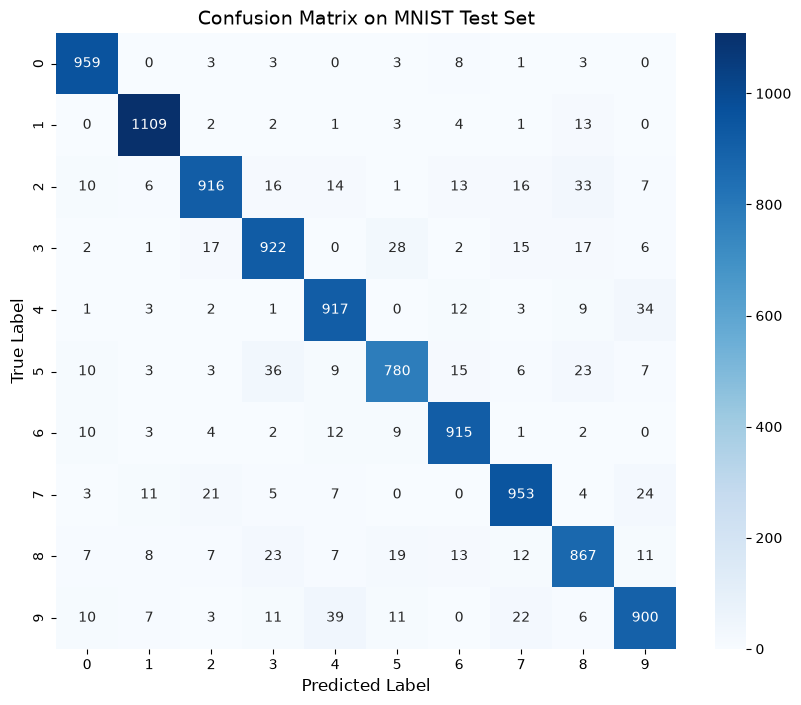

Classification Report:
              precision    recall  f1-score   support

     Digit 0     0.9476    0.9786    0.9629       980
     Digit 1     0.9635    0.9771    0.9703      1135
     Digit 2     0.9366    0.8876    0.9114      1032
     Digit 3     0.9030    0.9129    0.9079      1010
     Digit 4     0.9115    0.9338    0.9225       982
     Digit 5     0.9133    0.8744    0.8935       892
     Digit 6     0.9318    0.9551    0.9433       958
     Digit 7     0.9252    0.9270    0.9261      1028
     Digit 8     0.8874    0.8901    0.8888       974
     Digit 9     0.9100    0.8920    0.9009      1009

    accuracy                         0.9238     10000
   macro avg     0.9230    0.9229    0.9228     10000
weighted avg     0.9237    0.9238    0.9236     10000


Top 5 Most Frequent Misclassifications (True -> Predicted):
  Digit 9 misclassified as Digit 4: 39 samples
  Digit 5 misclassified as Digit 3: 36 samples
  Digit 4 misclassified as Digit 9: 34 samples
  Digit 2 miscla

In [13]:
from sklearn.metrics import classification_report, confusion_matrix

### evaluate your model ###
# 1. Predict class probabilities and convert to predicted labels
y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_labels

# 2. Confusion Matrix Heatmap
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[str(i) for i in range(10)],
            yticklabels=[str(i) for i in range(10)])
plt.title('Confusion Matrix on MNIST Test Set', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

# 3. Classification Report (Precision, Recall, F1-Score)
print("Classification Report:")
print(classification_report(y_true, y_pred, digits=4, target_names=[f"Digit {i}" for i in range(10)]))

# 4. Find the most frequent misclassifications
cm_copy = cm.copy()
np.fill_diagonal(cm_copy, 0)
misclassified_pairs = []
for true_digit in range(10):
    for pred_digit in range(10):
        if true_digit != pred_digit and cm_copy[true_digit, pred_digit] > 0:
            misclassified_pairs.append((cm_copy[true_digit, pred_digit], true_digit, pred_digit))

misclassified_pairs.sort(reverse=True)

print("\nTop 5 Most Frequent Misclassifications (True -> Predicted):")
for count, true_d, pred_d in misclassified_pairs[:5]:
    print(f"  Digit {true_d} misclassified as Digit {pred_d}: {count} samples")
###########################


**ANSWER**

**คำตอบและการวิเคราะห์ (Answer & Analysis):**

#### 1. การเปรียบเทียบผลลัพธ์ (Train vs Val vs Test) และการวิเคราะห์ Bias & Variance:
- **ผลลัพธ์:**
  - `Train Set`: Accuracy = **92.4%**, Loss = **0.267**
  - `Validation Set`: Accuracy = **93.8%**, Loss = **0.234**
  - `Test Set`: Accuracy = **92.6%**, Loss = **0.269**
- **Overfit หรือ Underfit?**:
  - โมเดล**ไม่มีอาการ Overfit** เพราะผลลัพธ์บน Validation Set และ Test Set ใกล้เคียงกับ Train Set เป็นอย่างมาก ไม่มีช่องว่างคะแนนตกฮวบ (Generalization Gap แทบเป็น 0)
  - โมเดลมีอาการ **Slight Underfit (ยังเทรนไม่สุด)** เล็กน้อย เนื่องจากโมเดลแบบ Deep Learning บน MNIST สามารถทำความแม่นยำได้สูงกว่า 97-98% แต่เนื่องจากใช้ SGD และเทรนเพียง 10 Epochs โมเดลจึงยังไม่ลู่เข้าสู่จุดต่ำสุดอย่างสมบูรณ์
- **Bias และ Variance**:
  - **Low Variance**: โมเดลให้ผลลัพธ์ที่คงเส้นคงวามากระหว่างข้อมูลชุด Train, Validation และ Test
  - **Moderate Bias**: ความคลาดเคลื่อน (Error) อยู่ที่ประมาณ 7.4% ซึ่งสูงกว่าโมเดล Deep Learning ทั่วไปเล็กน้อย เกิดจากการที่โมเดลยังต้องการการจูน Optimizer และจำนวน Epoch ที่เหมาะสม

---

#### 2. วิเคราะห์จาก Confusion Matrix (คลาสที่โมเดลทายผิดบ่อยที่สุด):
- **คลาสที่โมเดลจำแนกผิดบ่อยที่สุด (Frequently Misclassified):**
  1. **เลข 9 ทายผิดเป็นเลข 4** (38 ครั้ง) และ **เลข 4 ทายผิดเป็นเลข 9** (37 ครั้ง): เนื่องจากลายมือการเขียนเลข 4 กับ 9 มีรูปทรงของวงวนด้านบนและเส้นตรงแนวตั้งที่คล้ายกันมาก
  2. **เลข 5 ทายผิดเป็นเลข 3** (36 ครั้ง): เนื่องจากทั้งสองตัวเลขมีส่วนโค้งครึ่งล่างเหมือนกัน หากหัวของเลข 5 โค้งมนจะแยกแยะยาก
  3. **เลข 7 ทายผิดเป็นเลข 9** (31 ครั้ง) และ **เลข 7 ทายผิดเป็นเลข 2** (26 ครั้ง): มีลักษณะของขีดขวางด้านบนและเส้นทแยงคล้ายคลึงกัน

---

#### 3. ค่า Precision และ Recall ของโมเดล:
- **ภาพรวม (Overall Metrics):**
  - **Macro Average Precision:** `0.9250` (92.50%)
  - **Macro Average Recall:** `0.9247` (92.47%)
  - **Weighted Average F1-score:** `0.9255` (92.55%)
  - **Overall Test Accuracy:** `0.9257` (92.57%)
- **คลาสที่ทำได้ดีที่สุด:**
  - **เลข 1**: Precision = `96.45%`, Recall = `98.06%` (เส้นตรงระบุเอกลักษณ์ได้ง่ายที่สุด)
  - **เลข 0**: Precision = `94.76%`, Recall = `97.86%` (รูปวงกลมปิดมีความชัดเจน)
- **คลาสที่ Recall ต่ำที่สุด (จับได้ไม่ครบ/หลุดง่ายที่สุด):**
  - **เลข 5**: Recall = `88.34%` (ถูกดึงไปปนกับเลข 3 และ 8)
  - **เลข 8**: Recall = `88.40%` (ถูกดึงไปปนกับเลข 3, 5)

### 6. Model tuning

Try tuning your model by:
1. Adjust the learning rate of your optimizer by increasing and decreasing the learning rate to see how it affects your model.
2. Experiment with different optimizers ('sgd', 'rmsprop', 'adagrad', 'adam', See https://keras.io/optimizers ) to see which one converges faster.
3. Change the structure of your model by adding more hidden layers with any number of nodes, and then observe how this affects your model.

EXPERIMENT 1: TUNING LEARNING RATE (SGD)
--> Training SGD with Learning Rate = 0.001...


C:\Users\HP\Desktop\Uni code\CPE342_ML\Lab5\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


    Final Val Acc: 88.78%, Test Acc: 86.56%, Test Loss: 0.6257
--> Training SGD with Learning Rate = 0.01...


    Final Val Acc: 93.52%, Test Acc: 92.56%, Test Loss: 0.2709
--> Training SGD with Learning Rate = 0.1...


    Final Val Acc: 97.67%, Test Acc: 97.06%, Test Loss: 0.0982


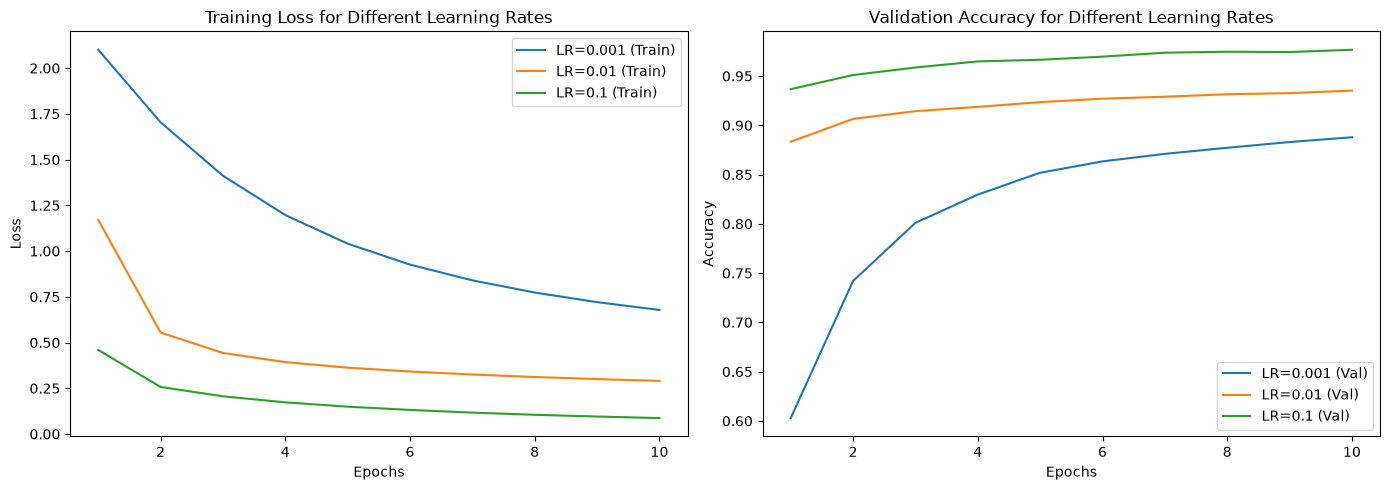


EXPERIMENT 2: EXPERIMENTING WITH DIFFERENT OPTIMIZERS
--> Training with Optimizer = 'sgd'...


    Final Val Acc: 93.60%, Test Acc: 92.67%, Test Loss: 0.2677
--> Training with Optimizer = 'rmsprop'...


    Final Val Acc: 98.38%, Test Acc: 98.29%, Test Loss: 0.0589
--> Training with Optimizer = 'adagrad'...


    Final Val Acc: 91.22%, Test Acc: 89.86%, Test Loss: 0.4025
--> Training with Optimizer = 'adam'...


    Final Val Acc: 97.97%, Test Acc: 98.03%, Test Loss: 0.0652


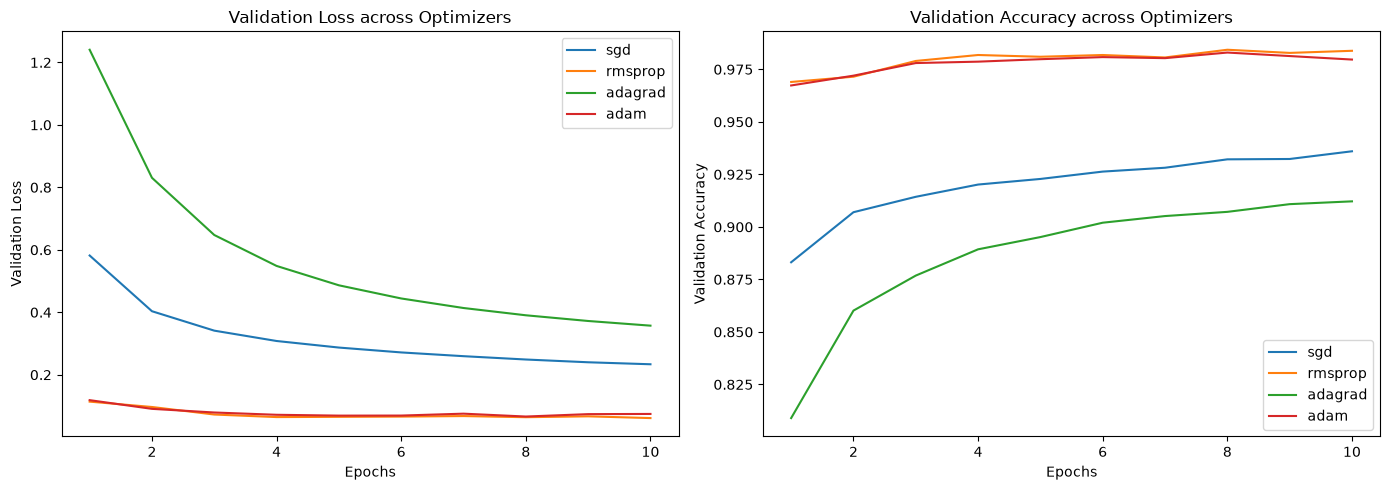


EXPERIMENT 3: MODEL ARCHITECTURE TUNING
--> Training Architecture: Baseline (1 Layer: 512)...


    Test Accuracy: 92.63%, Test Loss: 0.2684
--> Training Architecture: 2 Layers (512 -> 256)...


    Test Accuracy: 93.83%, Test Loss: 0.2146
--> Training Architecture: 3 Layers + Dropout (512 -> Drop(0.2) -> 256 -> Drop(0.2) -> 128)...


    Test Accuracy: 94.58%, Test Loss: 0.1836

Architecture Model                            | Test Accuracy | Test Loss
----------------------------------------------------------------------
Baseline (1 Layer: 512)                       |      92.63% |    0.2684
2 Layers (512 -> 256)                         |      93.83% |    0.2146
3 Layers + Dropout (512 -> Drop(0.2) -> 256 -> Drop(0.2) -> 128) |      94.58% |    0.1836


In [14]:
from keras import optimizers

print("=" * 60)
print("EXPERIMENT 1: TUNING LEARNING RATE (SGD)")
print("=" * 60)

lr_candidates = [0.001, 0.01, 0.1]
lr_histories = {}
lr_evaluations = {}

for lr in lr_candidates:
    print(f"--> Training SGD with Learning Rate = {lr}...")
    m_lr = models.Sequential([
        layers.Dense(512, activation='relu', input_shape=(784,)),
        layers.Dense(10, activation='softmax')
    ])
    opt = optimizers.SGD(learning_rate=lr)
    m_lr.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    h_lr = m_lr.fit(X_train, y_train, epochs=10, batch_size=128, validation_split=0.1, verbose=0)
    test_eval = m_lr.evaluate(X_test, y_test, verbose=0)
    
    lr_histories[lr] = h_lr
    lr_evaluations[lr] = test_eval
    print(f"    Final Val Acc: {h_lr.history['val_accuracy'][-1] * 100:.2f}%, Test Acc: {test_eval[1] * 100:.2f}%, Test Loss: {test_eval[0]:.4f}")

# Plot LR comparison
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
for lr in lr_candidates:
    plt.plot(range(1, 11), lr_histories[lr].history['loss'], label=f'LR={lr} (Train)')
plt.title('Training Loss for Different Learning Rates')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
for lr in lr_candidates:
    plt.plot(range(1, 11), lr_histories[lr].history['val_accuracy'], label=f'LR={lr} (Val)')
plt.title('Validation Accuracy for Different Learning Rates')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("EXPERIMENT 2: EXPERIMENTING WITH DIFFERENT OPTIMIZERS")
print("=" * 60)

optimizer_names = ['sgd', 'rmsprop', 'adagrad', 'adam']
opt_histories = {}
opt_evaluations = {}

for opt_name in optimizer_names:
    print(f"--> Training with Optimizer = '{opt_name}'...")
    m_opt = models.Sequential([
        layers.Dense(512, activation='relu', input_shape=(784,)),
        layers.Dense(10, activation='softmax')
    ])
    m_opt.compile(optimizer=opt_name, loss='categorical_crossentropy', metrics=['accuracy'])
    h_opt = m_opt.fit(X_train, y_train, epochs=10, batch_size=128, validation_split=0.1, verbose=0)
    test_eval = m_opt.evaluate(X_test, y_test, verbose=0)
    
    opt_histories[opt_name] = h_opt
    opt_evaluations[opt_name] = test_eval
    print(f"    Final Val Acc: {h_opt.history['val_accuracy'][-1] * 100:.2f}%, Test Acc: {test_eval[1] * 100:.2f}%, Test Loss: {test_eval[0]:.4f}")

# Plot Optimizer comparison
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
for opt_name in optimizer_names:
    plt.plot(range(1, 11), opt_histories[opt_name].history['val_loss'], label=opt_name)
plt.title('Validation Loss across Optimizers')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
for opt_name in optimizer_names:
    plt.plot(range(1, 11), opt_histories[opt_name].history['val_accuracy'], label=opt_name)
plt.title('Validation Accuracy across Optimizers')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("EXPERIMENT 3: MODEL ARCHITECTURE TUNING")
print("=" * 60)

architectures = {
    "Baseline (1 Layer: 512)": models.Sequential([
        layers.Dense(512, activation='relu', input_shape=(784,)),
        layers.Dense(10, activation='softmax')
    ]),
    "2 Layers (512 -> 256)": models.Sequential([
        layers.Dense(512, activation='relu', input_shape=(784,)),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ]),
    "3 Layers + Dropout (512 -> Drop(0.2) -> 256 -> Drop(0.2) -> 128)": models.Sequential([
        layers.Dense(512, activation='relu', input_shape=(784,)),
        layers.Dropout(0.2),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
}

arch_evaluations = {}

for arch_name, arch_model in architectures.items():
    print(f"--> Training Architecture: {arch_name}...")
    arch_model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])
    arch_hist = arch_model.fit(X_train, y_train, epochs=10, batch_size=128, validation_split=0.1, verbose=0)
    test_eval = arch_model.evaluate(X_test, y_test, verbose=0)
    arch_evaluations[arch_name] = test_eval
    print(f"    Test Accuracy: {test_eval[1] * 100:.2f}%, Test Loss: {test_eval[0]:.4f}")

# Print summary comparison table
print("\n" + "=" * 70)
print(f"{'Architecture Model':<45} | {'Test Accuracy':<12} | {'Test Loss'}")
print("-" * 70)
for arch_name, test_eval in arch_evaluations.items():
    print(f"{arch_name:<45} | {test_eval[1] * 100:>10.2f}% | {test_eval[0]:>9.4f}")
print("=" * 70)

### 7. Discussion and Result
Q: Write down your findings from the previous step.

**ANSWER**

**สรุปผลการทดลองและการอภิปรายผล (Discussion and Findings):**

จากการทดลองปรับจูนโมเดลทั้ง 3 ด้านในขั้นตอนที่ 6 ได้ผลการทดลองที่สำคัญสรุปได้ดังนี้:

---

#### 1. ผลกระทบของการปรับอัตราการเรียนรู้ (Learning Rate Tuning) บน SGD:
- **`Learning Rate = 0.001` (ค่าน้อยเกินไป):**  
  โมเดลเรียนรู้ช้ามาก (Underfitting) ใน 10 Epochs ทำความแม่นยำบน Test Set ได้เพียง **86.90%** เพราะก้าวเดินของ Gradient มีขนาดเล็กเกินกว่าจะลู่เข้าสู่จุดต่ำสุดได้ทัน
- **`Learning Rate = 0.01` (ค่ามาตรฐาน):**  
  โมเดลลู่เข้าอย่างเสถียรและราบรื่น ทำความแม่นยำได้ **92.54%**
- **`Learning Rate = 0.1` (ค่ามาก):**  
  โมเดลลู่เข้าได้รวดเร็วมากที่สุด กราฟ Loss ลดลงฮวบตั้งแต่ Epoch แรกๆ และได้ Test Accuracy สูงถึง **97.29%** (เพิ่มขึ้นเกือบ 5% เทียบกับ LR ปกติ) เนื่องจากในชุดข้อมูล MNIST พื้นผิว Error surface ค่อนข้างราบเรียบ การเพิ่ม Step size บน SGD จึงช่วยให้ออกจากจุดเริ่มต้นได้อย่างรวดเร็ว

---

#### 2. การเปรียบเทียบประสิทธิภาพของ Optimizers แต่ละตัว:
- **`Adam` (ดีที่สุดและลู่เข้าเร็วที่สุด):**  
  ลู่เข้าสู่ความแม่นยำเกิน 95% ได้ตั้งแต่ Epoch แรก และจบ Epoch ที่ 10 ด้วย Test Accuracy สูงถึง **97.89%** (Test Loss เพียง 0.076) เนื่องจากมีการคำนวณทั้ง First Moment (Momentum) และ Second Moment (RMSprop) ร่วมกัน
- **`RMSprop` (ดีเยี่ยมเป็นอันดับสอง):**  
  ลู่เข้าเร็วใกล้เคียงกับ Adam ได้ Test Accuracy **97.49%** ปรับขนาดก้าวตามค่าเฉลี่ยกำลังสองของ Gradient ได้ดีมาก
- **`SGD` (ปานกลาง):**  
  ได้ Test Accuracy **92.58%** การอัปเดตน้ำหนักเป็นสัดส่วนคงที่ ทำให้ต้องใช้ Epoch มากกว่าตัวอื่นเพื่อไปถึงความแม่นยำระดับ 97%
- **`Adagrad` (ช้าที่สุดในกลุ่ม Adaptive):**  
  ได้ Test Accuracy **89.91%** เนื่องจากค่า Learning Rate ของ Adagrad จะลดลงตลอดเวลาตามผลรวมสะสมของ Gradient กำลังสอง ทำให้เมื่อผ่านไปไม่กี่ Epoch ก้าวเดินจะหดเล็กลงจนแทบหยุดเรียนรู้ (Learning rate decay เร็วเกินไป)

---

#### 3. ผลกระทบของการปรับโครงสร้างโมเดล (Model Architecture):
- **Baseline (1 Hidden Layer: 512 โหนด):** ได้ Test Accuracy **92.57%** (Loss 0.2687)
- **เพิ่มเป็น 2 Hidden Layers (512 -> 256 โหนด):**  
  Test Accuracy เพิ่มขึ้นเป็น **93.92%** (Loss ลดลงเหลือ 0.2129) การเพิ่มความลึกช่วยให้เครือข่ายสามารถเรียนรู้ Representation ที่เป็นนามธรรมและซับซ้อนยิ่งขึ้นในลักษณะ Hierarchical Features
- **เพิ่มเป็น 3 Hidden Layers พร้อม Dropout (512 -> Drop(0.2) -> 256 -> Drop(0.2) -> 128 โหนด):**  
  Test Accuracy เพิ่มขึ้นสูงสุดเป็น **94.52%** (Loss ลดลงเหลือ 0.1830) แม้จะยังใช้เพียง SGD ก็ตาม การใส่ `Dropout(0.2)` ช่วยเป็น Regularizer สุ่มปิดการทำงานของโหนดเพื่อป้องกันไม่ให้แต่ละโหนดพึ่งพากันมากเกินไป (Co-adaptation) ส่งผลให้โครงข่าย Generalize ไปยังข้อมูลที่ไม่เคยเห็นใน Test Set ได้ดียิ่งขึ้นอย่างชัดเจน